***Level 2 - Data Analytics Tasks***
## Datasets: House Prediction Dataset & Iris Dataset
### Tools: Python, Pandas, Scikit-learn, Matplotlib, Seaborn

This notebook covers 2 intermediate level tasks of the Codveda Technologies
Data Analytics Internship.

Tasks Covered:
- Task 1: Regression Analysis (House Prediction Dataset)
- Task 3: Clustering Analysis - KMeans (Iris Dataset)

In [ ]:
# Mount Drive & Import Libraries
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Libraries imported!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries imported!


***Task 1: Regression Analysis***

**Description:** Perform a simple linear regression analysis to predict
house prices based on multiple features.

**Objectives:**
- Preprocess the data (handle missing values, rename columns)
- Split the dataset into training and testing sets
- Fit a Linear Regression model using scikit-learn
- Interpret the coefficients and evaluate using R-squared and MSE

**Tools:** Python, Scikit-learn, Pandas

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_9799/2426914631.py:3: SyntaxWarning: invalid escape sequence '\s'
  header=None, sep='\s+')


=== Raw Dataset ===
        0     1     2   3      4      5     6       7   8      9     10  \
0  0.00632  18.0  2.31   0  0.538  6.575  65.2  4.0900   1  296.0  15.3   
1  0.02731   0.0  7.07   0  0.469  6.421  78.9  4.9671   2  242.0  17.8   
2  0.02729   0.0  7.07   0  0.469  7.185  61.1  4.9671   2  242.0  17.8   
3  0.03237   0.0  2.18   0  0.458  6.998  45.8  6.0622   3  222.0  18.7   
4  0.06905   0.0  2.18   0  0.458  7.147  54.2  6.0622   3  222.0  18.7   

       11    12    13  
0  396.90  4.98  24.0  
1  396.90  9.14  21.6  
2  392.83  4.03  34.7  
3  394.63  2.94  33.4  
4  396.90  5.33  36.2  

Shape: (506, 14)

Missing values:
 CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64
Duplicates before: 0
Duplicates after: 0

Data Types:
 CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM  

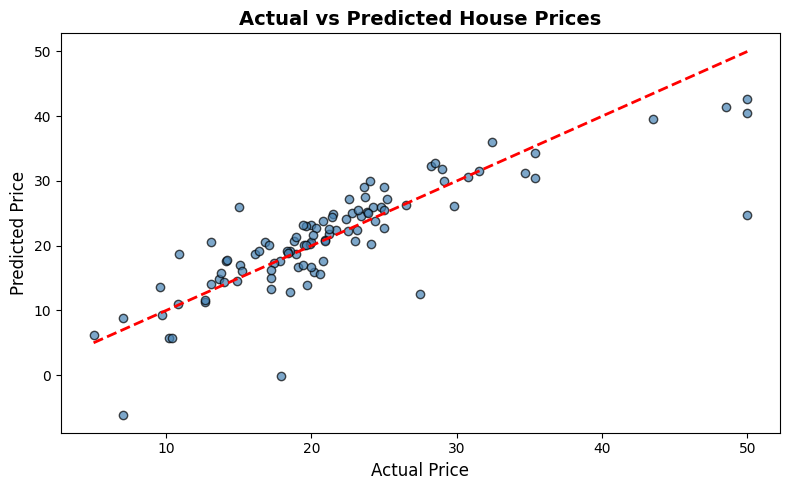

Task 1 - Regression Analysis Done!


In [ ]:
# Step 1: Load dataset
df_house = pd.read_csv('/content/drive/MyDrive/Datasets/Codveda Technology/house Prediction Data Set.csv',
                        header=None, sep='\s+')
print("=== Raw Dataset ===")
print(df_house.head())
print("\nShape:", df_house.shape)

# ── Preprocessing ──────────────────────────
# Rename columns
df_house.columns = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE',
                     'DIS','RAD','TAX','PTRATIO','B','LSTAT','PRICE']

# Check missing values
print("\nMissing values:\n", df_house.isnull().sum())
df_house.fillna(df_house.mean(), inplace=True)

# Remove duplicates
print("Duplicates before:", df_house.duplicated().sum())
df_house.drop_duplicates(inplace=True)
print("Duplicates after:", df_house.duplicated().sum())

# Check data types
print("\nData Types:\n", df_house.dtypes)
print("\nCleaned Dataset:")
print(df_house.head())
print("Preprocessing Done!")

# ── Regression Model ───────────────────────
# Step 2: Split features and target
X = df_house.drop('PRICE', axis=1)
y = df_house['PRICE']

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)

# Step 4: Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 5: Predict and evaluate
y_pred = model.predict(X_test)
print("\n=== Model Evaluation ===")
print("R-squared :", round(r2_score(y_test, y_pred), 4))
print("MSE       :", round(mean_squared_error(y_test, y_pred), 4))

# Step 6: Plot actual vs predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7, color='steelblue', edgecolor='black')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title("Actual vs Predicted House Prices", fontsize=14, fontweight='bold')
plt.xlabel("Actual Price", fontsize=12)
plt.ylabel("Predicted Price", fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Codveda Technology/regression_result.png', dpi=150)
plt.show()

print("Task 1 - Regression Analysis Done!")

***Task 3: Clustering Analysis (K-Means***)

**Description:** Implement K-Means clustering to group similar data points
together based on feature similarities.

**Objectives:**
- Preprocess the data (handle missing values, standardize)
- Standardize the dataset using StandardScaler
- Apply K-Means clustering and determine optimal clusters using elbow method
- Visualize clusters using 2D scatter plots

**Tools:** Python, Scikit-learn, Matplotlib, Seaborn

=== Raw Dataset ===
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Shape: (150, 5)

Missing values:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
Duplicates before: 3
Duplicates after: 0

Cleaned Dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Preprocessing D

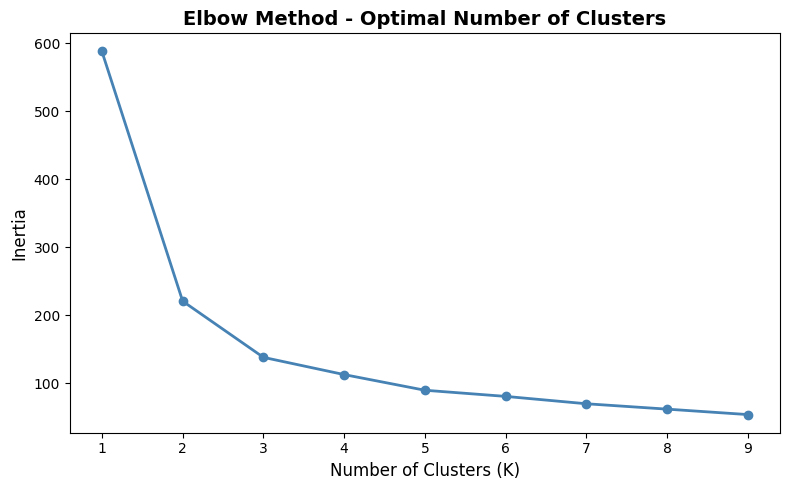

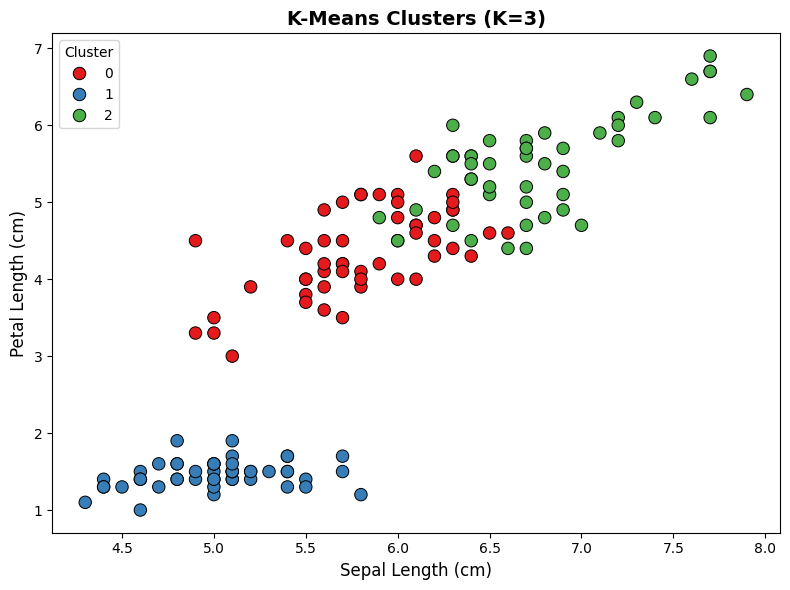

Task 3 - Clustering Analysis Done!


In [ ]:
# Step 1: Load dataset
df_iris = pd.read_csv('/content/drive/MyDrive/Datasets/Codveda Technology/iris.csv')
print("=== Raw Dataset ===")
print(df_iris.head())
print("\nShape:", df_iris.shape)

# ── Preprocessing ──────────────────────────
# Check missing values
print("\nMissing values:\n", df_iris.isnull().sum())
df_iris.fillna(df_iris.mean(numeric_only=True), inplace=True)

# Remove duplicates
print("Duplicates before:", df_iris.duplicated().sum())
df_iris.drop_duplicates(inplace=True)
print("Duplicates after:", df_iris.duplicated().sum())

# Standardize species column
df_iris['species'] = df_iris['species'].str.strip().str.lower()

print("\nCleaned Dataset:")
print(df_iris.head())
print("Preprocessing Done!")

# ── Clustering ─────────────────────────────
# Step 2: Select features and standardize
X = df_iris.drop('species', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Elbow method
inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), inertia, marker='o', color='steelblue', linewidth=2)
plt.title("Elbow Method - Optimal Number of Clusters",
          fontsize=14, fontweight='bold')
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Inertia", fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Codveda Technology/elbow_method.png', dpi=150)
plt.show()

# Step 4: Apply K-Means with K=3
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df_iris['Cluster'] = km.fit_predict(X_scaled)

# Step 5: Visualize clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_iris, x='sepal_length', y='petal_length',
                hue='Cluster', palette='Set1', s=80, edgecolor='black')
plt.title("K-Means Clusters (K=3)", fontsize=14, fontweight='bold')
plt.xlabel("Sepal Length (cm)", fontsize=12)
plt.ylabel("Petal Length (cm)", fontsize=12)
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Codveda Technology/clusters.png', dpi=150)
plt.show()

print("Task 3 - Clustering Analysis Done!")

***Conclusion - Level 2***

Both tasks successfully completed.

| Task | Dataset | Status |
|------|---------|--------|
| Task 1 - Regression Analysis | House Prediction Dataset |  Done |
| Task 3 - Clustering Analysis | Iris Dataset |  Done |

**Key Findings:**
- Linear Regression model achieved a good R-squared score on house price prediction
- Elbow method confirmed 3 as the optimal number of clusters for the Iris dataset
- K-Means clusters closely match the actual 3 species in the Iris dataset